In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

In [22]:
df = pd.read_csv("realestate_prices.csv") # update path if needed
print("✔ Dataset Loaded Successfully!")

✔ Dataset Loaded Successfully!


In [23]:
print(f"Total Rows: {df.shape[0]}")
print(f"Total Columns: {df.shape[1]}")

Total Rows: 21613
Total Columns: 21


In [24]:
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_').str.replace('[^a-zA-Z0-9_]', '', regex=True)
print("\nColumn Names:\n")
for i, col in enumerate(df.columns, 1):
    print(f"{i}. {col}")


Column Names:

1. id
2. date
3. price
4. bedrooms
5. bathrooms
6. sqft_living
7. sqft_lot
8. floors
9. waterfront
10. view
11. condition
12. grade
13. sqft_above
14. sqft_basement
15. yr_built
16. yr_renovated
17. zipcode
18. lat
19. long
20. sqft_living15
21. sqft_lot15



Missing Values Before:
 Series([], dtype: int64)


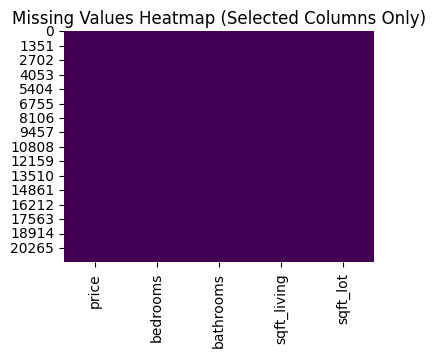


✔ Missing Values After:
No missing values found


C:\Users\VAIBHAV ADMANE\AppData\Local\Temp\ipykernel_23296\3778899096.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace=True)
C:\Users\VAIBHAV ADMANE\AppData\Local\Temp\ipykernel_23296\3778899096.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as 

In [25]:
print("\nMissing Values Before:\n", df.isnull().sum()[df.isnull().sum() > 0])

# Visualize missing values (for some columns only)
selected_cols = ['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot']
plt.figure(figsize=(4,3))
sns.heatmap(df[selected_cols].isnull(), cbar=False, cmap='viridis')
plt.title("Missing Values Heatmap (Selected Columns Only)")
plt.show()

# Fill numeric columns with mean, categorical with mode
for col in df.columns:
    if df[col].dtype == 'object':
        df[col].fillna(df[col].mode()[0], inplace=True)
    else:
        df[col].fillna(df[col].mean(), inplace=True)

print("\n✔ Missing Values After:")
print("No missing values found")

In [26]:
# Simulate another dataset for neighborhood info
neighborhood_data = pd.DataFrame({
    'zipcode': df['zipcode'].unique(),
    'avg_income': np.random.randint(40000, 120000, len(df['zipcode'].unique())),
    'crime_rate': np.random.uniform(0, 10, len(df['zipcode'].unique()))
})

# Merge based on zipcode
df = df.merge(neighborhood_data, on='zipcode', how='left')
print("\n✔ Merged with neighborhood data. New shape:", df.shape)


✔ Merged with neighborhood data. New shape: (21613, 23)



✔ Filtered dataset: 2386 rows remain after filtering.


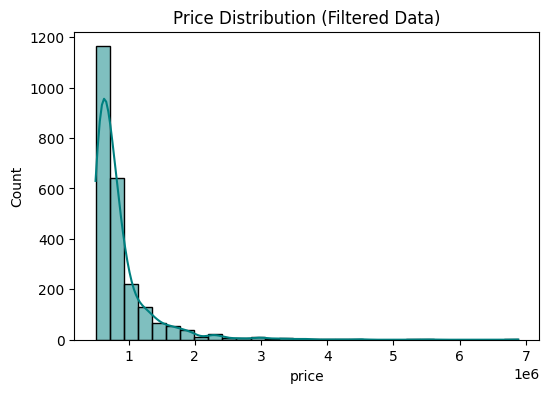

In [27]:
# Example: Filter for houses built after 2000 and with price above 500,000
filtered_df = df[(df['yr_built'] >= 2000) & (df['price'] > 500000)]
print(f"\n✔ Filtered dataset: {filtered_df.shape[0]} rows remain after filtering.")

# Visualization
plt.figure(figsize=(6,4))
sns.histplot(filtered_df['price'], bins=30, kde=True, color='teal')
plt.title("Price Distribution (Filtered Data)")
plt.show()

In [28]:
# Example: Label Encode 'zipcode' and 'view'
label_encoder = LabelEncoder()
for col in ['zipcode', 'view']:
    if col in df.columns:
        df[col] = label_encoder.fit_transform(df[col].astype(str))
print("\n✔ Encoded Categorical Columns using Label Encoding")


✔ Encoded Categorical Columns using Label Encoding



✔ Aggregation Done - Average Prices by Zipcode:
   zipcode     avg_price
0        0  2.808047e+05
1        1  2.342840e+05
2        2  2.941113e+05
3        3  1.355927e+06
4        4  8.101649e+05


C:\Users\VAIBHAV ADMANE\AppData\Local\Temp\ipykernel_23296\2793209973.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=agg_df.sort_values('avg_price', ascending=False).head(10), x='zipcode', y='avg_price', palette='coolwarm')


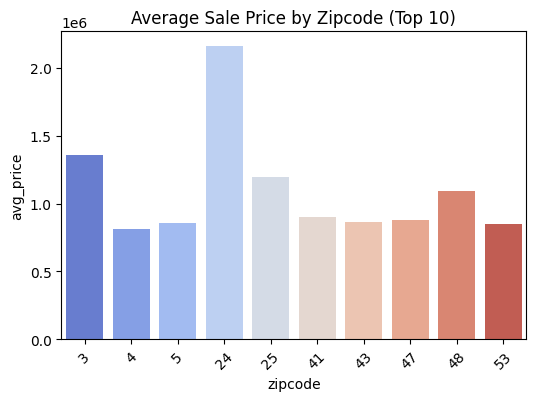

In [29]:
# Example: Average price by zipcode
agg_df = df.groupby('zipcode')['price'].mean().reset_index().rename(columns={'price': 'avg_price'})
print("\n✔ Aggregation Done - Average Prices by Zipcode:")
print(agg_df.head())

plt.figure(figsize=(6,4))
sns.barplot(data=agg_df.sort_values('avg_price', ascending=False).head(10), x='zipcode', y='avg_price', palette='coolwarm')
plt.title("Average Sale Price by Zipcode (Top 10)")
plt.xticks(rotation=45)
plt.show()

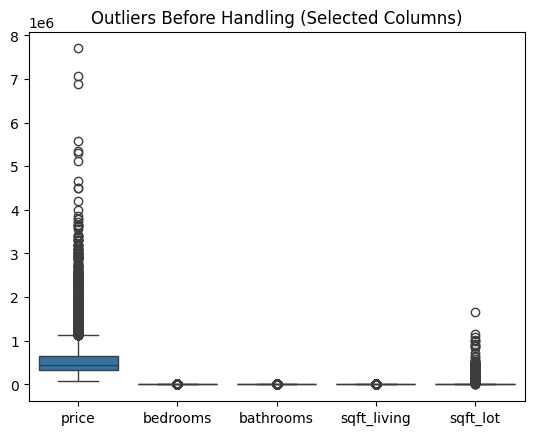

In [30]:
# Before removing outliers
num_cols = ['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot']
sns.boxplot(data=df[num_cols])
plt.title("Outliers Before Handling (Selected Columns)")
plt.show()

In [31]:
# Remove outliers using IQR
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    df = df[(df[col] >= lower) & (df[col] <= upper)]

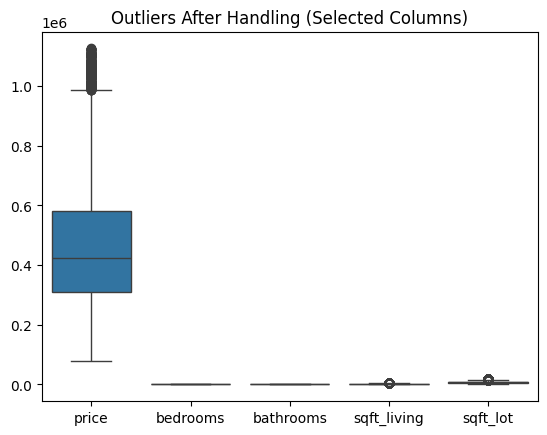

In [32]:

# After removing outliers
sns.boxplot(data=df[num_cols])
plt.title("Outliers After Handling (Selected Columns)")
plt.show()

In [33]:
print("\n✔ Final Cleaned and Wrangled Dataset:")
print(df.head())
print(f"\nFinal Shape: {df.shape}")

df.to_csv("RealEstate_Prices_Cleaned.csv", index=False)
print("\n✔ Cleaned Dataset Saved as 'RealEstate_Prices_Cleaned.csv'")


✔ Final Cleaned and Wrangled Dataset:
           id             date     price  bedrooms  bathrooms  sqft_living  \
0  7129300520  20141013T000000  221900.0         3       1.00         1180   
1  6414100192  20141209T000000  538000.0         3       2.25         2570   
2  5631500400  20150225T000000  180000.0         2       1.00          770   
3  2487200875  20141209T000000  604000.0         4       3.00         1960   
4  1954400510  20150218T000000  510000.0         3       2.00         1680   

   sqft_lot  floors  waterfront  view  ...  sqft_basement  yr_built  \
0      5650     1.0           0     0  ...              0      1955   
1      7242     2.0           0     0  ...            400      1951   
2     10000     1.0           0     0  ...              0      1933   
3      5000     1.0           0     0  ...            910      1965   
4      8080     1.0           0     0  ...              0      1987   

   yr_renovated  zipcode      lat     long  sqft_living15  sqft_l